# Analisis Rasio Harga vs Performa Mobil

Car Features & MSRP Dataset, diambil dari kaggle.com dengan link sebagai berikut:

https://www.kaggle.com/datasets/CooperUnion/cardataset/data

### Persiapan dan Pengambilan Dataset

Tahap awal dilakukan dengan mengimpor `kagglehub` dan mengunduh dataset **Car Features and MSRP** dari Kaggle. Dataset ini menjadi sumber data utama untuk analisis hubungan antara harga kendaraan dan karakteristik performanya.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("CooperUnion/cardataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cardataset' dataset.
Path to dataset files: /kaggle/input/cardataset


## 1. Business Understanding

### 1.1 Latar Belakang

Industri otomotif menyajikan beragam pilihan kendaraan dengan variasi harga dan spesifikasi teknis yang sangat luas. Calon pembeli maupun analis pasar sering kali kesulitan menilai apakah suatu mobil memiliki harga yang sepadan dengan performa yang ditawarkannya. Tanpa pemetaan yang objektif, penilaian rasio price-to-performance cenderung subjektif dan berisiko menghasilkan keputusan pembelian yang kurang tepat. Pengelompokan berbasis data diperlukan untuk memetakan segmen kendaraan berdasarkan keseimbangan antara nilai ekonomis dan performa teknis secara terukur.


### 1.2 Alasan Pemilihan Dataset

Dataset Car Features and MSRP dipilih karena memuat variabel finansial dan teknis kendaraan yang saling melengkapi. Atribut Engine HP dan highway MPG menjadi representasi utama dari sisi performa dan efisiensi, sementara MSRP mewakili nilai harga jual kendaraan. Kombinasi variabel numerik ini memungkinkan analisis rasio harga banding performa dilakukan secara langsung pada satu set data yang komprehensif.

### 1.3 Alasan Kelayakan Dataset untuk Clustering

Dataset ini sangat layak untuk algoritma clustering karena didominasi oleh variabel numerik kontinu tanpa adanya label kategori target awal. Hubungan antar-variabel seperti harga, tenaga mesin, dan efisiensi bahan bakar membentuk pola kelompok alami di dalam ruang data. Karakteristik ini membuat dataset ideal diolah menggunakan unsupervised learning untuk mengelompokkan kendaraan secara otomatis berdasarkan jarak kemiripan antar-fitur.


### 1.4 Pertanyaan Bisnis

* Bagaimana memetakan segmen pasar kendaraan berdasarkan rasio price-to-performance menggunakan teknik clustering?
* Secara spesifik, kelompok mobil mana saja yang masuk ke dalam segmen High Value, Standard Value, dan Overpriced?

## 2. Data Understanding


### 2.1 Load Dataset & Inspeksi Struktur Data
Tahap awal Data Understanding bertujuan untuk memuat dataset dan memeriksa struktur umum data mentah, meliputi jumlah baris, jumlah kolom, tipe data masing-masing variabel, serta tampilan sampel awal sebelum melakukan pemfilteran atau seleksi fitur.

#### a. Import Library

Library yang digunakan meliputi `Pandas` dan `NumPy` untuk pengolahan data, `Matplotlib` dan `Seaborn` untuk visualisasi, serta library pendukung lain yang digunakan pada tahap analisis dan pemodelan. Import dilakukan di awal agar seluruh kebutuhan analisis tersedia dalam satu notebook.


In [2]:
# Import library yang dibutuhkan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#### b. Memuat Dataset

Dataset hasil pengunduhan dimuat ke dalam DataFrame `df`. Lima baris pertama ditampilkan untuk memastikan data berhasil dibaca dan memberikan gambaran awal mengenai struktur serta atribut kendaraan yang tersedia.


In [3]:
# Load dataset
df = pd.read_csv('/root/.cache/kagglehub/datasets/CooperUnion/cardataset/versions/1/data.csv')

# Menampilkan 5 baris pertama data mentah
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


#### c. Pemeriksaan Dimensi Data

Dimensi dataset diperiksa untuk mengetahui jumlah baris dan kolom yang tersedia sebelum proses pembersihan. Informasi ini digunakan sebagai titik awal untuk melihat skala data yang akan dianalisis.


In [4]:
# Menampilkan dimensi dataset
print("Dimensi dataset:", df.shape)

Dimensi dataset: (11914, 16)


#### d. Pemeriksaan Struktur dan Tipe Data

Informasi setiap kolom diperiksa menggunakan `df.info()` untuk mengetahui tipe data dan jumlah nilai yang tersedia. Pemeriksaan ini membantu menentukan fitur yang dapat digunakan pada tahap analisis numerik dan mengidentifikasi kolom yang memerlukan perhatian lebih lanjut.


In [5]:
# Ringkasan informasi tipe data dan jumlah non-null
print("\nInformasi Tipe Data:")
df.info()


Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtype

### 2.2 Pemeriksaan Missing Values, Data Duplikat, dan Dataset
Pada tahap ini, dilakukan identifikasi terhadap nilai yang hilang (*missing values*) di seluruh fitur serta pengecekan keberadaan baris data yang duplikat untuk memastikan kualitas dan integritas dataset.

In [6]:
# Cek jumlah missing value per kolom
print("Jumlah Missing Values:")
print(df.isnull().sum())

Jumlah Missing Values:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [7]:
# Cek jumlah data duplikat
print("\nJumlah Data Duplikat:", df.duplicated().sum())


Jumlah Data Duplikat: 715


In [8]:
# Tandai baris mobil listrik
listrik = df['Engine Fuel Type'] == 'electric'

print("Jumlah baris mobil listrik:", listrik.sum())
print("Engine HP kosong pada mobil listrik:", df.loc[listrik, 'Engine HP'].isnull().sum())

Jumlah baris mobil listrik: 66
Engine HP kosong pada mobil listrik: 44


In [9]:
# Ringkasan highway MPG: True = mobil listrik, False = non-listrik
df.groupby(listrik)['highway MPG'].agg(['count', 'min', 'median', 'max'])

,count,min,median,max
Engine Fuel Type,,,,
False,11848,12,25.5,354
True,66,74,101.0,111


<Axes: title={'center': 'highway MPG'}, xlabel='Listrik'>

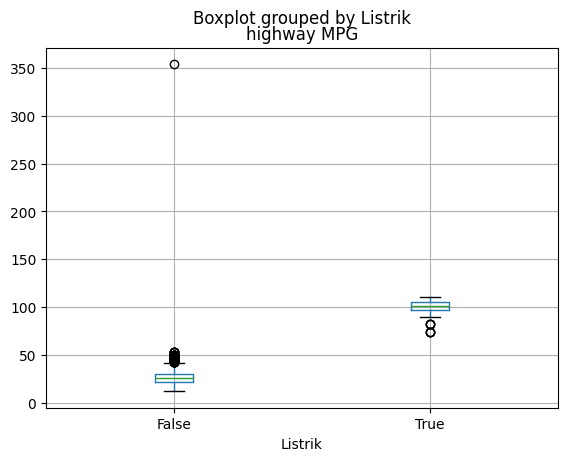

In [10]:
# Boxplot highway MPG per kelompok (Listrik: True/False)
df.assign(Listrik=listrik).boxplot(column='highway MPG', by='Listrik')

In [11]:
# MPG > 100 pada mobil non-listrik: kemungkinan salah input
df[(df['highway MPG'] > 100) & ~listrik][['Make', 'Model', 'Year', 'highway MPG']]

,Make,Model,Year,highway MPG
1119,Audi,A6,2017,354


### 2.3 Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat karakteristik dasar fitur numerik, seperti nilai rata-rata, standar deviasi, minimum, kuartil, dan maksimum. Informasi ini membantu memahami skala serta sebaran data sebelum dilakukan pemfilteran dan transformasi.


In [12]:
# Ringkasan statistik deskriptif kolom numerik
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


### 2.4 Visualisasi dataset

#### a. Visualisasi Sebaran Tahun Produksi

Visualisasi ini digunakan untuk melihat distribusi jumlah kendaraan berdasarkan tahun produksi. Hasilnya menjadi salah satu pertimbangan dalam menentukan rentang tahun yang relevan untuk ruang lingkup analisis.


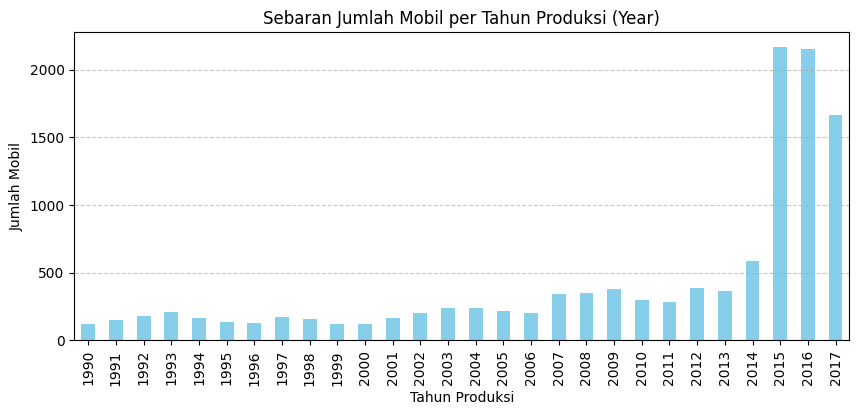

In [13]:
# 1. Sebaran Tahun Produksi
plt.figure(figsize=(10, 4))
df['Year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Sebaran Jumlah Mobil per Tahun Produksi (Year)')
plt.xlabel('Tahun Produksi')
plt.ylabel('Jumlah Mobil')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### b. Analisis Median MSRP Berdasarkan Tahun

Median `MSRP` dibandingkan pada setiap tahun produksi untuk melihat pola perubahan harga kendaraan. Visualisasi ini digunakan sebagai salah satu dasar empiris dalam menentukan batasan tahun pada tahap Data Preparation.


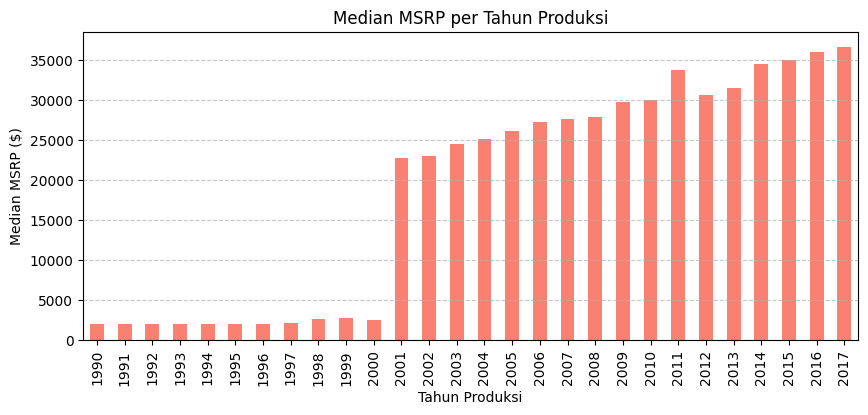

In [14]:
# 2. Median MSRP per Tahun
plt.figure(figsize=(10, 4))
df.groupby('Year')['MSRP'].median().plot(kind='bar', color='salmon')
plt.title(
    'Median MSRP per Tahun Produksi'
)
plt.xlabel('Tahun Produksi')
plt.ylabel('Median MSRP ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### c. Distribusi Jenis Bahan Bakar

Distribusi jenis bahan bakar diperiksa untuk mengetahui karakteristik kendaraan dalam dataset. Informasi ini digunakan untuk mengidentifikasi kelompok kendaraan yang perlu dikeluarkan agar ruang lingkup analisis tetap sesuai dengan tujuan project.


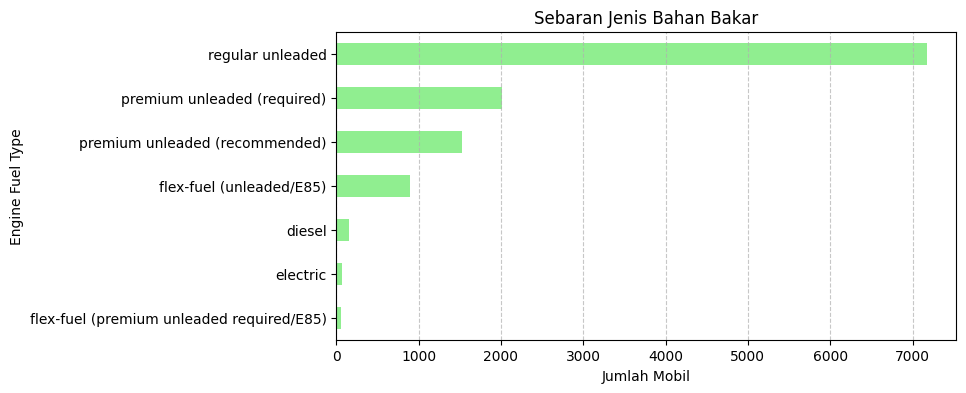

In [15]:
# 3. Sebaran Jenis Bahan Bakar (Landasan Membuang Mobil Listrik)
plt.figure(figsize=(8, 4))
df['Engine Fuel Type'].value_counts().head(7).plot(
    kind='barh', color='lightgreen'
)
plt.title('Sebaran Jenis Bahan Bakar')
plt.xlabel('Jumlah Mobil')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### d. Pemeriksaan Outlier Fitur Numerik

Boxplot digunakan untuk melihat keberadaan nilai ekstrem pada `Engine HP` dan `highway MPG`. Pemeriksaan ini membantu menentukan apakah terdapat observasi yang secara statistik tidak wajar dan perlu ditinjau sebelum clustering.


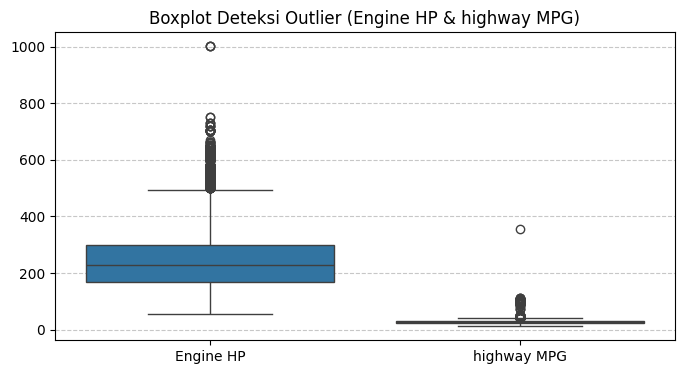

In [16]:
# 4. Boxplot Outlier Fitur Numerik
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[['Engine HP', 'highway MPG']])
plt.title('Boxplot Deteksi Outlier (Engine HP & highway MPG)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### e. Hubungan Engine HP dan MSRP

Scatter plot digunakan untuk mengamati hubungan antara tenaga mesin (`Engine HP`) dan harga kendaraan (`MSRP`). Sumbu harga menggunakan skala logaritmik agar perbedaan harga yang sangat lebar dapat divisualisasikan dengan lebih jelas.


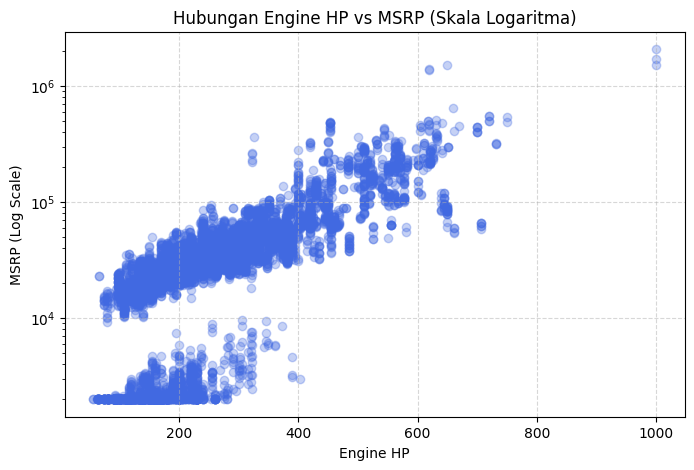

In [17]:
# 5. Scatter Plot Engine HP vs MSRP (Skala Logaritma)
plt.figure(figsize=(8, 5))
plt.scatter(df['Engine HP'], df['MSRP'], alpha=0.3, color='royalblue')
plt.yscale('log')
plt.title('Hubungan Engine HP vs MSRP (Skala Logaritma)')
plt.xlabel('Engine HP')
plt.ylabel('MSRP (Log Scale)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### f. Korelasi Antarvariabel

Heatmap korelasi Spearman digunakan untuk melihat kekuatan hubungan monotonic antarvariabel numerik yang dipertimbangkan. Analisis ini membantu memahami keterkaitan antara performa, efisiensi, harga, dan tahun sebelum pembentukan fitur clustering.


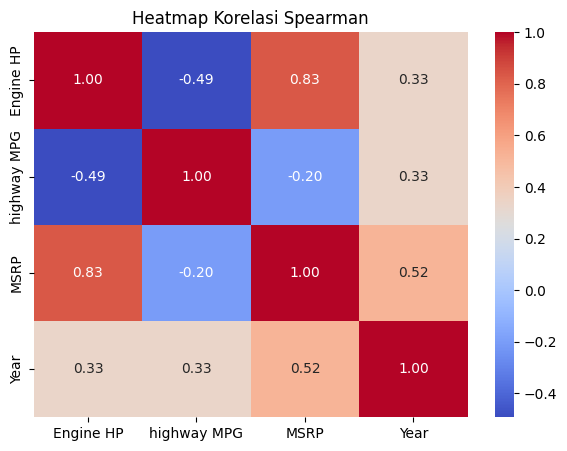

In [18]:
# 6. Heatmap Korelasi Spearman
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['Engine HP', 'highway MPG', 'MSRP', 'Year']].corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)
plt.title('Heatmap Korelasi Spearman')
plt.show()

In [19]:
# Korelasi Spearman untuk variabel yang tidak divisualisasikan, dibandingkan dengan fitur utama
df[['Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'MSRP', 'Popularity']].corr(method='spearman').round(2)

,Engine HP,Engine Cylinders,highway MPG,city mpg,MSRP,Popularity
Engine HP,1.00,0.75,-0.49,-0.58,0.83,0.03
Engine Cylinders,0.75,1.00,-0.77,-0.84,0.47,0.02
highway MPG,-0.49,-0.77,1.00,0.95,-0.20,0.01
city mpg,-0.58,-0.84,0.95,1.00,-0.27,0.02
MSRP,0.83,0.47,-0.20,-0.27,1.00,0.00
Popularity,0.03,0.02,0.01,0.02,0.00,1.00


### 2.5 Analisis singkat

Dataset Car Features and MSRP terdiri dari 11.914 data dan 16 atribut numerik serta kategorikal. Pemeriksaan kualitas data menemukan missing values (terbanyak pada Market Category sejumlah 3.742) dan 715 data duplikat yang wajib ditangani saat Data Preparation. Selain itu, atribut MSRP, Engine HP, dan highway MPG memiliki rentang nilai yang sangat lebar dan bervariasi ekstrem, misalnya MSRP yang berkisar 2.000–2.065.902 dollar, sehingga MSRP memerlukan transformasi skala sebelum proses clustering dan pemodelan.

Visualisasi difokuskan pada Engine HP, highway MPG, dan MSRP (melalui boxplot, scatter plot, dan korelasi Spearman) untuk menganalisis sebaran, outlier, dan hubungan performa, efisiensi, serta harga. Year dan Engine Fuel Type divisualisasikan khusus untuk menentukan skop data (membatasi tahun dan mengecualikan kendaraan listrik). Variabel lain tidak divisualisasikan karena redundan (city mpg berkorelasi 0,95 dengan highway MPG), memiliki korelasi lebih lemah (Engine Cylinders), tidak berkorelasi (Popularity), bersifat kategorikal non-performa (Transmission, Driven_Wheels, Vehicle Size/Style, Market Category yang banyak missing values), atau sekadar identitas unit (Make dan Model).

Temuan lain menjadi dasar keputusan pada tahap Data Preparation. Median `MSRP` pada 1990–1996 tepat 2.000 dollar dan baru normal mulai 2001, sehingga data tahun awal tidak valid dan rentang dibatasi pada 2010–2017. Kendaraan listrik memiliki `Engine HP` kosong pada sebagian besar barisnya dan `highway MPG` dalam satuan MPGe yang tidak sebanding dengan mobil bensin, sehingga dikecualikan. Ditemukan pula nilai `highway MPG` sebesar 354 pada Audi A6 2017 yang merupakan kesalahan input, serta kendaraan dengan `MSRP` hingga jutaan dollar (mobil hypercar) yang berada di luar segmen pembeli umum, sehingga model dengan `MSRP` di atas $300.000 dikeluarkan.

## 3. Data Preparation

### 3.1 Pemfilteran Skop Data dan Agregasi Unit Analisis
Pada tahap ini, data duplikat dihapus terlebih dahulu, kemudian dilakukan pemfilteran skop analisis sesuai batasan project (tahun 2010–2017, kendaraan non-listrik, dan MSRP ≤ $300k).

Selanjutnya, data diagregasi berdasarkan unit analisis **`Make + Model`** dengan mengambil nilai median untuk fitur `Engine HP`, `highway MPG`, dan `MSRP`. Pendekatan agregasi ini secara otomatis mengatasi *missing values* pada `Engine HP` menggunakan nilai spesifik dari tiap model, sehingga menghindari *data contamination* akibat imputasi median global.

#### a. Pemfilteran Data Sesuai Ruang Lingkup

Data duplikat dan data yang tidak sesuai dengan ruang lingkup analisis dihapus. Filter mencakup batas tahun produksi, pengecualian kendaraan listrik, serta pembatasan `highway MPG` agar observasi yang digunakan lebih relevan dengan tujuan segmentasi.


In [20]:
# Hapus duplikat dan filter skop analisis
df_scoped = df.drop_duplicates()
df_scoped = df_scoped[
    (df_scoped['Year'] >= 2010)
    & (df_scoped['Engine Fuel Type'] != 'electric')
    & (df_scoped['highway MPG'] < 100)
]
print("Baris mentah:", df.shape[0], "| setelah filter:", df_scoped.shape[0])

Baris mentah: 11914 | setelah filter: 7491


#### b. Agregasi Unit Analisis

Data diagregasikan berdasarkan kombinasi `Make` dan `Model` sehingga unit analisis berubah dari baris kendaraan individual menjadi model kendaraan. Nilai median digunakan untuk `Engine HP`, `highway MPG`, dan `MSRP` agar representasi setiap model lebih stabil terhadap nilai ekstrem.


In [21]:
# Agregasi ke unit analisis (Make + Model)
cols = ['Engine HP', 'highway MPG', 'MSRP']
df_grouped = df_scoped.groupby(['Make', 'Model'])[cols].median().reset_index()
print("Jumlah model:", df_grouped.shape[0])
print("Missing Engine HP:", df_grouped['Engine HP'].isnull().sum())

Jumlah model: 525
Missing Engine HP: 0


#### c. Pembatasan Harga dan Transformasi MSRP

Model dengan `MSRP` di atas batas analisis dikeluarkan untuk mengurangi pengaruh kendaraan dengan harga yang sangat ekstrem. Selanjutnya, `MSRP` ditransformasi menggunakan `log1p` untuk mengurangi skewness sebelum digunakan dalam pembentukan fitur dan analisis hubungan harga-performa.


In [22]:
# Membuat ambang batas harga msrp di 300k
df_grouped = df_grouped[df_grouped['MSRP'] <= 300000].copy()
df_grouped['log_MSRP'] = np.log1p(df_grouped['MSRP'])
print("Jumlah model akhir:", df_grouped.shape[0])
df_grouped.describe()

Jumlah model akhir: 507


,Engine HP,highway MPG,MSRP,log_MSRP
count,507.000000,507.000000,507.000000,507.000000
mean,295.702170,27.210059,58034.002959,10.702761
std,131.658781,6.243317,54920.219347,0.660501
min,74.000000,14.000000,14085.000000,9.552937
25%,196.000000,23.000000,27948.750000,10.238162
50%,276.000000,26.000000,39150.000000,10.575181
75%,350.000000,31.000000,58105.000000,10.970020
max,662.000000,53.000000,298995.000000,12.608185


### 3.2 Standarisasi Fitur dan Pembentukan Value Gap
Sebelum masuk ke algoritma klustering, fitur utama (`Engine HP`, `highway MPG`, dan `log_MSRP`) distandarisasi menggunakan `StandardScaler` agar perbedaan skala antarvariabel tidak mendominasi perhitungan jarak Euclidean. Selain itu, dibentuk indikator `value_gap` untuk merepresentasikan posisi harga relatif kendaraan terhadap performanya.

#### a. Standardisasi Fitur Utama

Tiga fitur utama, yaitu `Engine HP`, `highway MPG`, dan `log_MSRP`, distandarisasi menggunakan `StandardScaler`. Standardisasi dilakukan agar fitur dengan skala numerik berbeda memiliki kontribusi yang lebih seimbang ketika digunakan dalam perhitungan jarak pada clustering.


In [23]:
from sklearn.preprocessing import StandardScaler

# 1. Inisialisasi StandardScaler
scaler = StandardScaler()
features_primary = ['Engine HP', 'highway MPG', 'log_MSRP']

# 2. Transformasi skala fitur utama
features_scaled = scaler.fit_transform(df_grouped[features_primary])
df_grouped[['Engine HP_scaled', 'highway MPG_scaled', 'log_MSRP_scaled']] = features_scaled

# 3. Tampilkan 5 sampel awal data yang sudah distandarisasi
print("Hasil Standarisasi Fitur (5 Baris Pertama):")
df_grouped[['Make', 'Model', 'Engine HP_scaled', 'highway MPG_scaled', 'log_MSRP_scaled']].head()

Hasil Standarisasi Fitur (5 Baris Pertama):


,Make,Model,Engine HP_scaled,highway MPG_scaled,log_MSRP_scaled
0,Acura,ILX,-0.720010,1.248957,-0.599546
1,Acura,ILX Hybrid,-1.404271,1.729945,-0.510846
2,Acura,MDX,-0.043353,-0.033679,0.188242
3,Acura,NSX,2.108266,-0.835326,1.901732
4,Acura,RDX,-0.126985,0.126651,-0.192573


#### b. Pembentukan Value Gap

Model regresi digunakan untuk membentuk nilai pembanding antara harga yang diamati dan harga yang diperkirakan berdasarkan karakteristik performa. Selisih tersebut disimpan sebagai `value_gap` untuk merepresentasikan posisi relatif harga kendaraan terhadap performanya.


In [24]:
from sklearn.linear_model import LinearRegression

perf = np.column_stack([np.log(df_grouped['Engine HP']), df_grouped['highway MPG']])
reg = LinearRegression().fit(perf, df_grouped['log_MSRP'])
df_grouped['value_gap'] = df_grouped['log_MSRP'] - reg.predict(perf)

## 4. Modeling

### 4.1 Fitur dan scaling

#### a. Menentukan Fitur Clustering

Fitur yang digunakan pada model utama terdiri dari `Engine HP`, `highway MPG`, dan `value_gap`. Ketiga fitur tersebut distandarisasi kembali sebelum diterapkan pada algoritma K-Means agar proses pengelompokan tidak didominasi oleh perbedaan skala antarvariabel.


In [25]:
from sklearn.preprocessing import StandardScaler

# Menentukan fitur dan scaling
features_value = ['Engine HP', 'highway MPG', 'value_gap']
scaler_value = StandardScaler()
X_value = scaler_value.fit_transform(df_grouped[features_value])

#### b. Menentukan Jumlah Cluster

Beberapa nilai `K` diuji menggunakan rentang 2 hingga 8 cluster. Nilai `inertia` dan `Silhouette Score` dihitung untuk membantu melihat perubahan kualitas pemisahan kelompok dan menentukan jumlah cluster yang sesuai untuk analisis.


   Inertia  Silhouette
K                     
2  964.839       0.335
3  607.223       0.388
4  493.199       0.322
5  420.799       0.324
6  360.054       0.318
7  316.773       0.305
8  290.488       0.292


array([<Axes: xlabel='K'>, <Axes: xlabel='K'>], dtype=object)

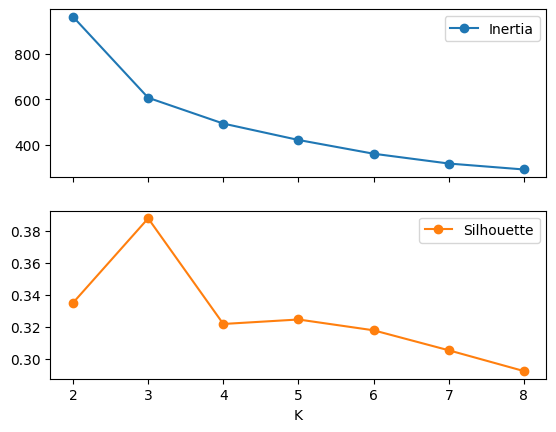

In [26]:
# Menentukan K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertia, sil = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_value)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_value, km.labels_))

eval_k = pd.DataFrame({'K': k_range, 'Inertia': inertia, 'Silhouette': sil}).set_index('K')
print(eval_k.round(3))
eval_k.plot(subplots=True, marker='o')

#### c. Perbandingan Algoritma Clustering

K-Means digunakan sebagai model clustering utama dan dibandingkan dengan pendekatan clustering lain. Perbandingan ini dilakukan untuk melihat apakah struktur kelompok yang diperoleh relatif konsisten terhadap metode yang berbeda.


In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# K-Means utama dan model pembanding
df_grouped['Cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_value)
cluster_agg = AgglomerativeClustering(n_clusters=3).fit_predict(X_value)
cluster_gmm = GaussianMixture(n_components=3, random_state=42).fit_predict(X_value)

print("Silhouette K-Means     :", round(silhouette_score(X_value, df_grouped['Cluster']), 4))
print("Silhouette Agglomerative:", round(silhouette_score(X_value, cluster_agg), 4))
print("Silhouette GMM         :", round(silhouette_score(X_value, cluster_gmm), 4))
print("ARI K-Means vs Agglo   :", round(adjusted_rand_score(df_grouped['Cluster'], cluster_agg), 3))
print("ARI K-Means vs GMM     :", round(adjusted_rand_score(df_grouped['Cluster'], cluster_gmm), 3))

Silhouette K-Means     : 0.3877
Silhouette Agglomerative: 0.3627
Silhouette GMM         : 0.2395
ARI K-Means vs Agglo   : 0.687
ARI K-Means vs GMM     : 0.361


#### d. Pembentukan Model K-Means Final

Model K-Means dengan tiga cluster digunakan sebagai model utama berdasarkan hasil analisis sebelumnya. Objek model disimpan dalam variabel `kmeans_final` agar dapat digunakan kembali pada tahap deployment dan prediksi data baru.


In [28]:
# Simpan objek K-Means agar bisa disimpan di tahap Deployment
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_grouped['Cluster'] = kmeans_final.fit_predict(X_value)

#### e. Pelabelan Segmen

Nomor cluster dari K-Means bersifat arbitrer sehingga tidak langsung memiliki makna bisnis. Oleh karena itu, cluster diurutkan berdasarkan median `value_gap`, kemudian diberi nama segmen **High Value**, **Standard Value**, dan **Overpriced / Low Value** agar hasil clustering lebih mudah diinterpretasikan.


In [29]:
# Pelabelan
order = df_grouped.groupby('Cluster')['value_gap'].median().sort_values().index
names = ['High Value', 'Standard Value', 'Overpriced / Low Value']
label_map = dict(zip(order, names))
df_grouped['Segmen'] = df_grouped['Cluster'].map(label_map)

#### f. Profiling Setiap Segmen

Setiap segmen diringkas menggunakan jumlah model, median `Engine HP`, `highway MPG`, `MSRP`, dan `value_gap`. Profil ini digunakan untuk memahami karakteristik utama dari masing-masing kelompok kendaraan.


In [30]:
df_grouped.groupby('Segmen').agg(
    Jumlah=('Model', 'count'),
    HP=('Engine HP', 'median'),
    MPG=('highway MPG', 'median'),
    MSRP=('MSRP', 'median'),
    value_gap=('value_gap', 'median'),
).round(2)

,Jumlah,HP,MPG,MSRP,value_gap
Segmen,,,,,
High Value,223,311.0,24.0,44540.00,-0.19
Overpriced / Low Value,60,547.0,20.0,194257.50,0.50
Standard Value,224,184.5,32.0,27876.25,0.05


#### g. Pembandingan dengan Fitur Alternatif

Clustering tambahan dilakukan menggunakan fitur terstandarisasi yang berbeda sebagai pembanding. Hasilnya digunakan untuk melihat seberapa konsisten struktur cluster utama ketika fitur yang digunakan mengalami perubahan.


In [31]:
# Pembanding cluster
X_tier = df_grouped[['Engine HP_scaled', 'highway MPG_scaled', 'log_MSRP_scaled']]
df_grouped['Cluster_A'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_tier)

print("Silhouette Opsi A:", round(silhouette_score(X_tier, df_grouped['Cluster_A']), 4))
print("ARI Opsi A vs B  :", round(adjusted_rand_score(df_grouped['Cluster'], df_grouped['Cluster_A']), 3))
pd.crosstab(df_grouped['Cluster_A'], df_grouped['Segmen'])

Silhouette Opsi A: 0.4467
ARI Opsi A vs B  : 0.478


Segmen,High Value,Overpriced / Low Value,Standard Value
Cluster_A,,,
0,29,58,0
1,192,2,67
2,2,0,157


## 5. Evaluation

### 5.1 Evaluasi Metrik dan Profiling Segmen Mobil
Tahap ini bertujuan untuk mengukur kualitas pemisahan *cluster* secara objektif menggunakan metrik *Silhouette Score*, *Davies-Bouldin Index*, dan *Calinski-Harabasz Score*, serta melakukan interprestasi karakteristik bisnis dari setiap kelompok.

#### a. Evaluasi Kualitas Cluster

Tiga metrik digunakan untuk mengevaluasi kualitas clustering, yaitu **Silhouette Score**, **Davies-Bouldin Index**, dan **Calinski-Harabasz Index**. Metrik tersebut memberikan sudut pandang berbeda mengenai kekompakan dan keterpisahan antar-cluster.


In [32]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hitung tiga metrik kualitas cluster pada model utama (K-Means K=3, fitur X_value)
sil = silhouette_score(X_value, df_grouped['Cluster'])
db = davies_bouldin_score(X_value, df_grouped['Cluster'])
ch = calinski_harabasz_score(X_value, df_grouped['Cluster'])

print(f"Silhouette Score       : {sil:.4f}")
print(f"Davies-Bouldin Index   : {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.2f}")

Silhouette Score       : 0.3877
Davies-Bouldin Index   : 0.8845
Calinski-Harabasz Score: 379.22


#### b. Uji Stabilitas Clustering

K-Means dijalankan kembali menggunakan beberapa nilai `random_state` untuk memeriksa kestabilan hasil pengelompokan. **Adjusted Rand Index (ARI)** digunakan untuk membandingkan kesesuaian pembagian cluster dengan hasil model utama.


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Latih ulang K-Means dengan seed berbeda, lalu bandingkan hasilnya dengan model utama
# ARI = 1 artinya pembagian cluster identik
for seed in [1, 7, 99]:
    ulang = KMeans(n_clusters=3, random_state=seed, n_init=10).fit_predict(X_value)
    print(f"Seed {seed}: ARI = {adjusted_rand_score(df_grouped['Cluster'], ulang):.3f}")

Seed 1: ARI = 1.000
Seed 7: ARI = 1.000
Seed 99: ARI = 1.000


### 5.2 Visualisasi Sebaran Cluster

#### a. Visualisasi Cluster: Engine HP vs Value Gap

Sebaran kendaraan divisualisasikan berdasarkan `Engine HP` dan `value_gap`, kemudian dibedakan berdasarkan segmen. Visualisasi ini membantu melihat pola hubungan performa dengan posisi harga relatif pada hasil clustering.


<Axes: xlabel='Engine HP', ylabel='value_gap'>

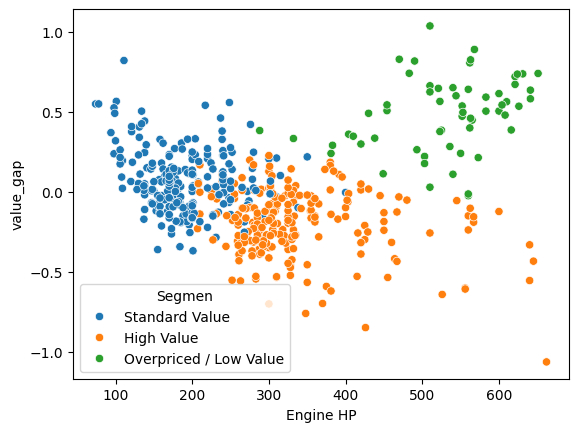

In [34]:
import seaborn as sns

# Sebaran HP vs value_gap (dua dari tiga fitur klustering), diwarnai per segmen
sns.scatterplot(data=df_grouped, x='Engine HP', y='value_gap', hue='Segmen')

#### b. Visualisasi Cluster: Engine HP vs MSRP

Hubungan antara tenaga mesin dan harga kendaraan divisualisasikan berdasarkan segmen hasil clustering. Skala logaritmik digunakan pada sumbu `MSRP` agar rentang harga yang lebar tetap dapat diamati dengan lebih jelas.


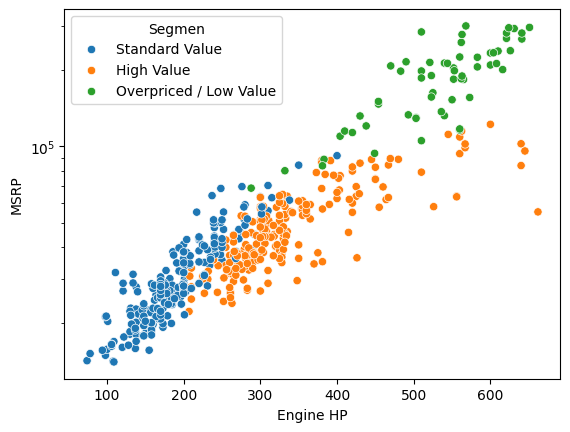

In [35]:
# Sebaran HP vs MSRP dengan skala log pada sumbu harga, diwarnai per segmen
sns.scatterplot(data=df_grouped, x='Engine HP', y='MSRP', hue='Segmen').set_yscale('log')

#### c. Contoh Model pada Segmen High Value

Beberapa model dengan `value_gap` paling rendah pada segmen **High Value** ditampilkan sebagai contoh. Tabel ini digunakan untuk melihat kendaraan yang secara relatif memiliki posisi harga lebih rendah dibandingkan estimasi berdasarkan karakteristik performanya.


In [36]:
show = ['Make', 'Model', 'Engine HP', 'highway MPG', 'MSRP', 'value_gap']

# 8 model paling murah relatif terhadap performanya di segmen High Value
df_grouped[df_grouped['Segmen'] == 'High Value'].sort_values('value_gap').head(8)[show].round(2)

,Make,Model,Engine HP,highway MPG,MSRP,value_gap
203,Ford,Shelby GT500,662.0,24.0,55110.0,-1.06
124,Chevrolet,Camaro,426.0,25.0,36300.0,-0.85
244,Hyundai,Genesis Coupe,348.0,25.0,29500.0,-0.76
138,Chevrolet,Impala Limited,300.0,30.0,26840.0,-0.70
161,Dodge,Charger,370.0,25.0,34342.5,-0.70
202,Ford,Shelby GT350,526.0,21.0,57795.0,-0.64
487,Toyota,Tundra,381.0,17.0,35040.0,-0.62
111,Cadillac,CTS-V Wagon,556.0,19.0,63215.0,-0.61


#### d. Contoh Model pada Segmen Overpriced / Low Value

Beberapa model dengan `value_gap` paling tinggi pada segmen **Overpriced / Low Value** ditampilkan untuk memperlihatkan contoh kendaraan yang memiliki harga relatif tinggi dibandingkan estimasi berbasis performanya.


In [37]:
# 8 model paling mahal relatif terhadap performanya di segmen Overpriced
df_grouped[df_grouped['Segmen'] == 'Overpriced / Low Value'].sort_values(
    'value_gap', ascending=False).head(8)[show].round(2)

,Make,Model,Engine HP,highway MPG,MSRP,value_gap
15,Aston Martin,DBS,510.0,17.5,283097.5,1.04
21,Aston Martin,Vanquish,568.0,21.0,298995.0,0.89
16,Aston Martin,Rapide,470.0,19.0,207895.0,0.83
434,Rolls-Royce,Ghost,563.0,21.0,276600.0,0.82
22,Aston Martin,Virage,490.0,18.0,215795.0,0.82
175,Ferrari,458 Italia,562.0,17.0,257412.0,0.81
178,Ferrari,California,483.0,19.0,198190.0,0.74
181,Ferrari,FF,651.0,16.0,295000.0,0.74


#### e. Sanity Check Pelabelan Segmen

Beberapa model kendaraan yang umum dikenal dipilih untuk melihat apakah hasil pelabelan segmen masih dapat dipahami secara masuk akal. Pemeriksaan ini bersifat interpretatif dan digunakan sebagai pengecekan tambahan, bukan sebagai pengganti evaluasi metrik clustering.


In [38]:
# Cek apakah label segmen masuk akal untuk model yang umum dikenal
dikenal = ['Camry', 'Civic', 'Corolla', 'Accord', 'Mustang', 'Corvette', 'Ghost', 'Prius', 'MX-5 Miata']
df_grouped[df_grouped['Model'].isin(dikenal)][
    ['Make', 'Model', 'Engine HP', 'highway MPG', 'MSRP', 'value_gap', 'Segmen']].round(2)

,Make,Model,Engine HP,highway MPG,MSRP,value_gap,Segmen
129,Chevrolet,Corvette,460.0,25.0,69170.0,-0.32,High Value
200,Ford,Mustang,310.0,27.5,32347.5,-0.53,High Value
221,Honda,Accord,185.0,34.0,27190.0,-0.03,Standard Value
227,Honda,Civic,158.0,40.0,22300.0,-0.08,Standard Value
359,Mazda,MX-5 Miata,158.0,28.0,28650.0,0.33,Standard Value
434,Rolls-Royce,Ghost,563.0,21.0,276600.0,0.82,Overpriced / Low Value
469,Toyota,Camry,178.0,33.0,26230.0,0.00,Standard Value
471,Toyota,Corolla,132.0,37.0,19865.0,0.11,Standard Value
478,Toyota,Prius,121.0,50.0,26860.0,0.38,Standard Value


#### f. Perbandingan dengan Baseline Naif

Hasil clustering dibandingkan dengan baseline sederhana yang membagi kendaraan menjadi tiga kelompok berdasarkan rasio `MSRP` terhadap `Engine HP`. Perbandingan ini digunakan untuk melihat apakah pendekatan clustering memberikan segmentasi yang berbeda dari pembagian berdasarkan satu rasio harga-performa sederhana.


In [39]:
# Baseline naif: bagi model menjadi 3 kelompok berdasarkan harga per HP (tercile)
df_grouped['harga_per_hp'] = df_grouped['MSRP'] / df_grouped['Engine HP']
df_grouped['Baseline'] = pd.qcut(df_grouped['harga_per_hp'], 3, labels=['Low', 'Mid', 'High'])

# Bandingkan dengan segmen hasil klustering: tabel silang dan ARI
print(pd.crosstab(df_grouped['Baseline'], df_grouped['Segmen']))
print("ARI Baseline vs Segmen:", round(adjusted_rand_score(df_grouped['Baseline'], df_grouped['Segmen']), 3))

Segmen    High Value  Overpriced / Low Value  Standard Value
Baseline                                                    
Low              106                       0              63
Mid               75                       0              94
High              42                      60              67
ARI Baseline vs Segmen: 0.08


### 5.3 Kesimpulan Evaluation

Evaluasi kuantitatif menunjukkan bahwa K-Means ($K=3$) menghasilkan kualitas pemisahan yang sedang, dengan *Silhouette Score* 0,3877, *Davies-Bouldin Index* 0,8845, dan *Calinski-Harabasz Score* 379,22. Nilai $K=3$ didukung data karena *Silhouette Score* tertinggi terjadi pada $K=3$ dibandingkan $K=2$ (0,335) dan $K=4$ (0,322). K-Means juga unggul atas *Agglomerative Clustering* (0,3627) dan GMM (0,2395), serta sangat stabil pada tiga *seed* berbeda (*Adjusted Rand Index* = 1,0).

Berdasarkan median `value_gap` (selisih harga aktual terhadap harga lazim berbasis performa dan efisiensi), terbentuk tiga segmen:

1. **High Value (223 model):** bertenaga menengah–tinggi (median 311 HP, 24 MPG) dengan harga di bawah harga lazim (median 44.540 dollar, `value_gap` -0,19). Contoh: Ford Shelby GT500 dan Chevrolet Camaro.
2. **Standard Value (224 model):** mobil ekonomis dan paling irit (median 185 HP, 32 MPG) dengan harga wajar (median 27.876 dollar, `value_gap` +0,05). Contoh: Toyota Camry dan Honda Civic.
3. **Overpriced / Low Value (60 model):** berperforma sangat tinggi dan boros (median 547 HP, 20 MPG) dengan harga jauh di atas harga lazim (median 194.258 dollar, `value_gap` +0,50). Contoh: Aston Martin dan Ferrari.

Sebagai pembanding, klaster berbasis tingkatan pasar (HP, MPG, log harga) menghasilkan *Silhouette Score* lebih tinggi (0,4467), tetapi ruang fiturnya berbeda sehingga nilainya tidak dapat dibandingkan langsung. Kemiripannya dengan segmentasi berbasis nilai hanya 0,48, dan satu cluster kelas atas terbagi menjadi 58 model *Overpriced* dan 29 model *High Value*, sehingga tingkat harga saja tidak cukup untuk menilai kewajaran harga. Baseline naif berupa tercile harga per HP juga sangat berbeda dari hasil klaster (ARI 0,08).

Keterbatasan analisis ini:
* label diberikan pada tingkat cluster sehingga model individual dapat menyimpang, misalnya Toyota Prius (`value_gap` +0,38) dan Mazda MX-5 Miata (+0,33) tergolong *Standard Value* meskipun lebih mahal dari harga lazim
* segmen *Overpriced* hanya berisi mobil mewah sehingga lebih mencerminkan premi merek dan kemewahan; (3) `value_gap` diukur relatif terhadap harga pasar pada data itu sendiri (2010–2017, USD), bukan nilai yang dirasakan pembeli, sehingga segmentasi sensitif terhadap definisi harga lazim tersebut.

## 6. Deployment

### 6.1 Export Model Artifacts dan Fungsi Prediksi Data Baru
Menyimpan model K-Means, StandardScaler, serta dataset hasil klustering ke dalam format file `.pkl` dan `.csv`. Dibuat pula fungsi inferensi untuk memprediksi segmen pasar dari masukan data mobil baru secara otomatis.

#### a. Menyimpan Model dan Artifact

Model K-Means, scaler, model regresi, serta pemetaan label disimpan dalam satu bundle menggunakan `joblib`. Artifact tersebut diperlukan agar proses prediksi pada data baru dapat menggunakan preprocessing dan model yang sama seperti pada tahap training.


In [40]:
import joblib

# Satu file berisi semua objek yang dibutuhkan untuk memprediksi data baru:
# regresi (untuk value_gap), scaler, K-Means, dan pemetaan label cluster
PATH = '/content/model_segmentasi_mobil.pkl'
joblib.dump({
    'reg': reg,
    'scaler': scaler_value,
    'kmeans': kmeans_final,
    'label_map': label_map,
}, PATH)

# Simpan juga tabel hasil klustering
df_grouped.to_csv('/content/hasil_segmentasi_mobil.csv', index=False)
print("Artifact berhasil disimpan.")

Artifact berhasil disimpan.


#### b. Fungsi Prediksi Segmen Data Baru

Fungsi `prediksi_segmen()` dibuat untuk menerima input `Engine HP`, `highway MPG`, dan `MSRP`, kemudian menjalankan seluruh tahapan preprocessing hingga menentukan segmen kendaraan. Validasi input dasar juga dilakukan untuk mencegah nilai yang tidak valid diproses oleh model.


In [41]:
# Muat kembali artifact yang tadi disimpan
bundle = joblib.load(PATH)

def prediksi_segmen(hp, mpg, msrp):
    # Validasi input dasar
    if hp <= 0 or mpg <= 0 or msrp <= 0:
        raise ValueError("hp, mpg, dan msrp harus > 0")
    if msrp > 300000:
        print("Peringatan: harga di atas $300k berada di luar cakupan data latih.")

    # 1. Hitung value_gap: harga aktual dikurangi harga yang diprediksi dari HP dan MPG
    pred_log_msrp = bundle['reg'].predict([[np.log(hp), mpg]])[0]
    value_gap = np.log1p(msrp) - pred_log_msrp

    # 2. Standarisasi dengan urutan fitur yang sama seperti saat pelatihan
    x = pd.DataFrame([[hp, mpg, value_gap]],
                     columns=['Engine HP', 'highway MPG', 'value_gap'])
    x_scaled = bundle['scaler'].transform(x)

    # 3. Prediksi cluster, lalu ubah menjadi nama segmen
    cluster = bundle['kmeans'].predict(x_scaled)[0]
    return bundle['label_map'][cluster], round(float(value_gap), 3)

#### c. Contoh Prediksi Data Baru

Sebuah contoh kendaraan baru diberikan sebagai input untuk menguji fungsi prediksi. Output yang dihasilkan berupa nama segmen dan nilai `value_gap` sebagai indikator posisi harga relatif kendaraan terhadap performanya.


In [42]:
# Contoh mobil baru: 150 HP, 35 MPG, harga $22.000 (USD)
segmen, gap = prediksi_segmen(hp=150, mpg=35, msrp=22000)
print("Segmen:", segmen, "| value_gap:", gap)

Segmen: Standard Value | value_gap: 0.05


#### d. Uji Konsistensi Model

Prediksi ulang dilakukan pada seluruh data yang telah digunakan dalam pembentukan cluster untuk memastikan pipeline deployment menghasilkan label segmen yang konsisten dengan hasil clustering yang tersimpan.


In [43]:
# Uji konsistensi: prediksi ulang seluruh data latih, hasilnya harus sama dengan label asli
cocok = sum(
    prediksi_segmen(r['Engine HP'], r['highway MPG'], r['MSRP'])[0] == r['Segmen']
    for _, r in df_grouped.iterrows()
)
print(f"Konsisten: {cocok} dari {len(df_grouped)} model")

Konsisten: 507 dari 507 model
